In [97]:
#Carregar as bibliotecas

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os
import cv2
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.math import confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
tf.keras.utils.set_random_seed(4)
tf.config.experimental.enable_op_determinism()

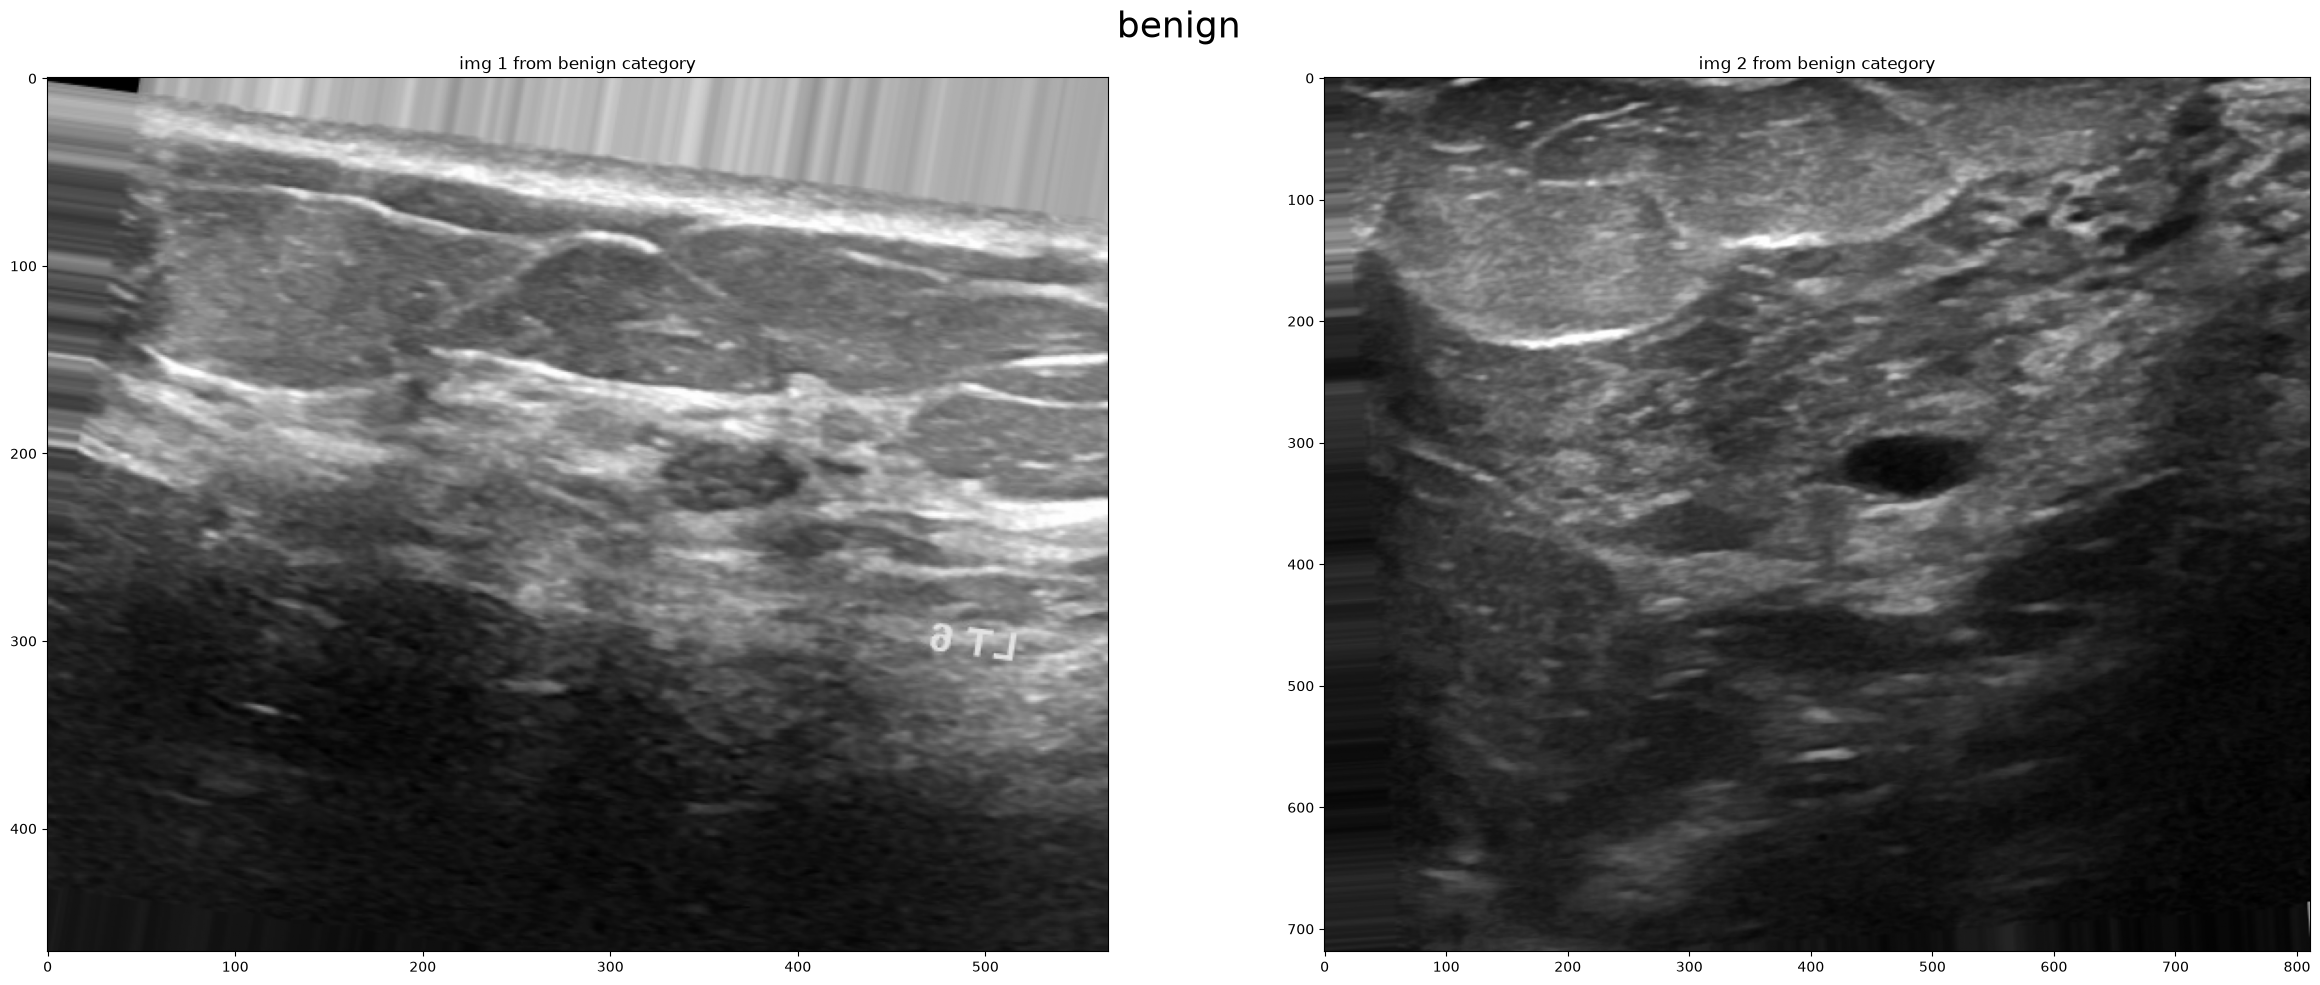

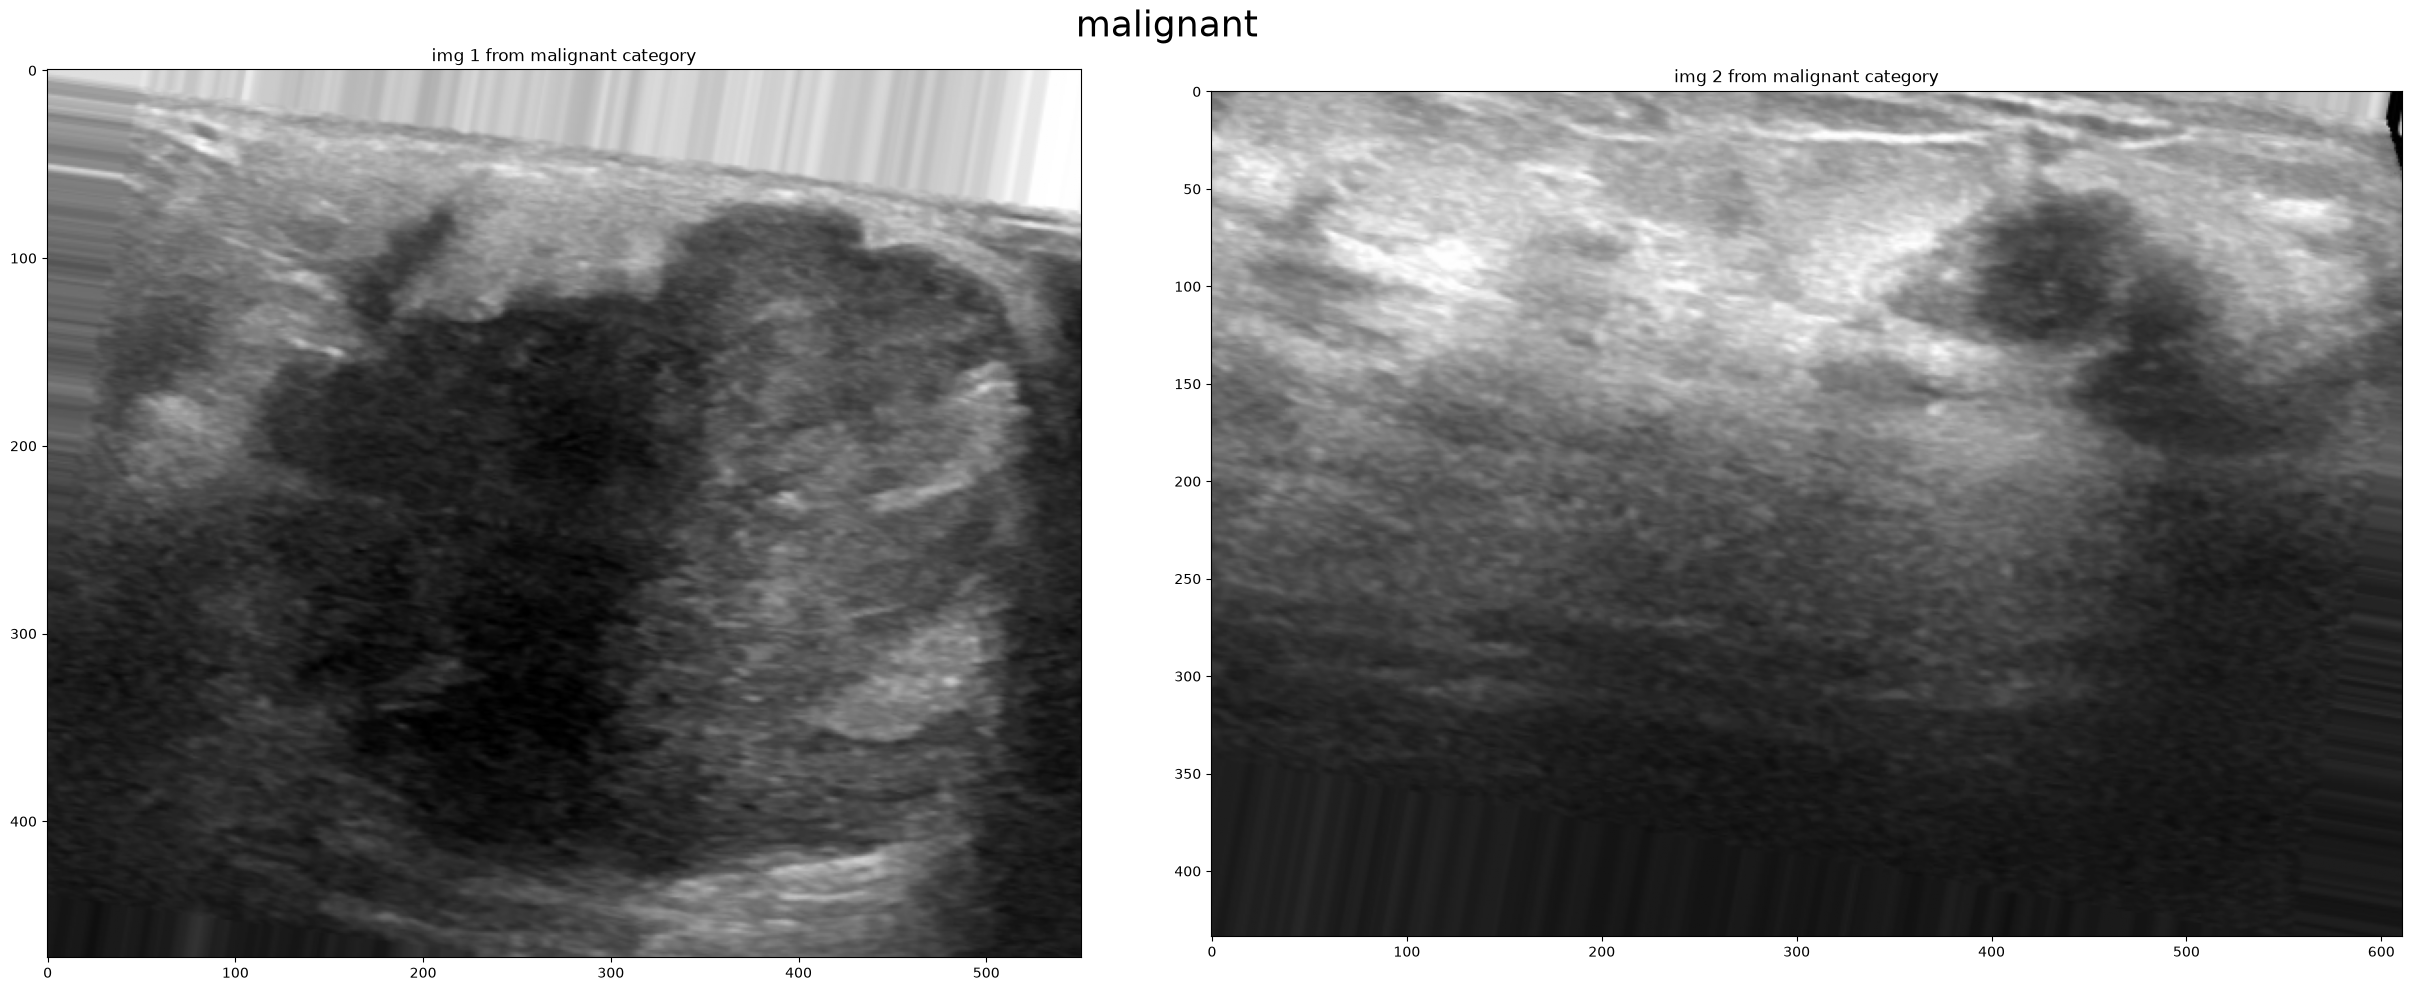

In [98]:
#Dados sobre conjunto de imagens de ultrassom de mama que contém 2 Classes [benigno, maligno] Exibindo 2 imagens de cada classe

import os
import cv2
import matplotlib.pyplot as plt

# Novo caminho da base de dados
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/train_augmented'
files_names = ['benign', 'malignant']  # Apenas as duas classes desejadas

for file in files_names:
    path = os.path.join(folder_name, file)
    x = 0
    fig, axes = plt.subplots(1, 2, figsize=(25, 10))  
    
    for img in os.listdir(path):
        if not img.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue  # Ignora arquivos que não são imagens

        img_path = os.path.join(path, img)
        if not os.path.isfile(img_path):
            continue  # Garante que é um arquivo

        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            continue  # Ignora arquivos corrompidos ou inválidos

        axes[x].imshow(img_array, cmap='gray')
        axes[x].set_title(f"img {x+1} from {file} category")
        x += 1
        if x == 2: 
            break

    plt.suptitle(file, fontsize=26)
    plt.tight_layout()
    plt.show()

In [99]:
# Carregando dados

import os
import cv2
from tqdm import tqdm

# Caminho para a pasta contendo as imagens de treino
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/train_augmented'

# Classes que queremos carregar
files_names = ['benign', 'malignant']

# Tamanho das imagens
img_sz = 224

# Lista para armazenar os dados de treino
training_data = []

def create_training_data():
    for file in files_names:
        path = os.path.join(folder_name, file)
        class_num = files_names.index(file)  # 0 para benign, 1 para malignant
        print(file, class_num)

        for img in tqdm(os.listdir(path)):
            img_path = os.path.join(path, img)

            # Filtros para evitar imagens indesejadas
            if not img.lower().endswith('.png'):
                continue
            if not os.path.isfile(img_path):
                continue

            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_array is None:
                continue  # evita erro se a imagem estiver corrompida

            new_array = cv2.resize(img_array, (img_sz, img_sz))
            training_data.append([new_array, class_num])

# Executar a função
create_training_data()


benign 0


100%|█████████████████████████████████████| 1302/1302 [00:03<00:00, 362.59it/s]


malignant 1


100%|███████████████████████████████████████| 744/744 [00:01<00:00, 387.99it/s]


In [100]:
# Os dados têm imagens benignas e malignas. Embaralhando e exibindo as primeiras 20 classes

import random

# Embaralha os dados de treino
random.shuffle(training_data)

# Exibe as primeiras 30 amostras com suas classes
for i in range(30):
    print(f"Sample {i+1}:")
    print("Class number:", training_data[i][1], "\n")


Sample 1:
Class number: 0 

Sample 2:
Class number: 0 

Sample 3:
Class number: 0 

Sample 4:
Class number: 0 

Sample 5:
Class number: 0 

Sample 6:
Class number: 0 

Sample 7:
Class number: 0 

Sample 8:
Class number: 1 

Sample 9:
Class number: 0 

Sample 10:
Class number: 0 

Sample 11:
Class number: 0 

Sample 12:
Class number: 1 

Sample 13:
Class number: 0 

Sample 14:
Class number: 1 

Sample 15:
Class number: 0 

Sample 16:
Class number: 1 

Sample 17:
Class number: 0 

Sample 18:
Class number: 0 

Sample 19:
Class number: 1 

Sample 20:
Class number: 0 

Sample 21:
Class number: 1 

Sample 22:
Class number: 1 

Sample 23:
Class number: 0 

Sample 24:
Class number: 1 

Sample 25:
Class number: 0 

Sample 26:
Class number: 0 

Sample 27:
Class number: 1 

Sample 28:
Class number: 0 

Sample 29:
Class number: 0 

Sample 30:
Class number: 1 



In [101]:
import numpy as np

X = []
y = []

# Percorre as amostras de treinamento
for feature, label in training_data:
    X.append(feature)
    y.append(label)

# Converte as listas em arrays numpy
X = np.array(X)
y = np.array(y)

# Adiciona a dimensão para o canal (escala de cinza)
X = np.expand_dims(X, axis=-1)  # Adiciona a dimensão do canal de cor (1 para grayscale)

# Verificando a forma de X e y
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (2046, 224, 224, 1)
y shape: (2046,)


In [102]:
from sklearn.model_selection import train_test_split

# Divisão dos dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar as formas dos conjuntos de dados
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(1636, 224, 224, 1)
(1636,)
(410, 224, 224, 1)
(410,)


In [103]:
# Valores únicos em y (Classes)

print(np.unique(y_train))

print(np.unique(y_test))

[0 1]
[0 1]


In [104]:
# Normalização para 0-1
X_train = X_train/255
X_test = X_test/255

In [105]:
import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models

def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]
    
    shared_layer_one = layers.Dense(channel // ratio,
                                    activation='relu',
                                    kernel_initializer='he_normal',
                                    use_bias=True,
                                    bias_initializer='zeros')
    shared_layer_two = layers.Dense(channel,
                                    kernel_initializer='he_normal',
                                    use_bias=True,
                                    bias_initializer='zeros')

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)

    cbam_feature = layers.Add()([avg_pool, max_pool])
    cbam_feature = layers.Activation('sigmoid')(cbam_feature)

    return layers.Multiply()([input_feature, cbam_feature])

def spatial_attention(input_feature):
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(input_feature)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(input_feature)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    cbam_feature = layers.Conv2D(filters=1,
                                 kernel_size=7,
                                 strides=1,
                                 padding='same',
                                 activation='sigmoid',
                                 kernel_initializer='he_normal',
                                 use_bias=False)(concat)
    return layers.Multiply()([input_feature, cbam_feature])

# Em ultrassom (textura fina), ratios menores funcionam melhor.
def cbam_block(input_feature, ratio=4): #Ajustar o ratio do Channel Attention
    feature = channel_attention(input_feature, ratio)
    feature = spatial_attention(feature)
    return feature

# Agora o modelo com CBAM
img_sz = 224  # Exemplo de tamanho de imagem

inputs = layers.Input(shape=(img_sz, img_sz, 1))
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = cbam_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = cbam_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(128, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = cbam_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(256, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = cbam_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(2, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [106]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 224, 224,  │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_24[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv2d_24[0][0]   │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_24          │ (None, 1, 1, 32)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_25          │ (None, 1, 1, 32)  │          0 │ global_max_pooli… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 1, 1, 8)   │        264 │ reshape_24[0][0], │
│                     │                   │            │ reshape_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 1, 1, 32)  │        288 │ dense_33[0][0],   │
│                     │                   │            │ dense_33[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 1, 1, 32)  │          0 │ dense_34[0][0],   │
│                     │                   │            │ dense_34[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 1, 1, 32)  │          0 │ add_12[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_24         │ (None, 224, 224,  │          0 │ conv2d_24[0][0],  │
│ (Multiply)          │ 32)               │            │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_24 (Lambda)  │ (None, 224, 224,  │          0 │ multiply_24[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_25 (Lambda)  │ (None, 224, 224,  │          0 │ multiply_24[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 224, 224,  │          0 │ lambda_24[0][0],  │
│ (Concatenate)       │ 2)                │            │ lambda_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 224, 224,  │         98 │ concatenate_12[0… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_25         │ (None, 224, 224,  │          0 │ multiply_24[0][0… │
│ (Multiply)          │ 32)               │            │ conv2d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ multiply_25[0][0

 Total params: 475,554 (1.81 MB)

 Trainable params: 474,594 (1.81 MB)

 Non-trainable params: 960 (3.75 KB)

In [107]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',  # ou 'val_accuracy'
                               patience=10,          # número de épocas sem melhora antes de parar
                               restore_best_weights=True)  # restaura os melhores pesos

history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_split=0.2,
                    batch_size=8,
                    callbacks=[early_stopping])

Epoch 1/50


E0000 00:00:1786176794.320222    3772 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


164/164 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.6904 - loss: 0.5866 - val_accuracy: 0.3445 - val_loss: 1.1390
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.7561 - loss: 0.4990 - val_accuracy: 0.3445 - val_loss: 1.7611
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.7982 - loss: 0.4418 - val_accuracy: 0.3445 - val_loss: 3.8253
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8249 - loss: 0.3993 - val_accuracy: 0.5701 - val_loss: 1.0321
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8486 - loss: 0.3487 - val_accuracy: 0.8384 - val_loss: 0.3668
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8616 - loss: 0.3013 - val_accuracy: 0.8201 - val_loss: 0.4110
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8930 - loss: 0.2678 - val_accuracy: 0.7317 - val_loss: 0.4645
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8830 - loss: 0.2655 - val_accuracy: 0.66

In [108]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuarcy of the model is : {accuracy*100:.2f} %")

E0000 00:00:1786176939.292159    3772 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9024 - loss: 0.3251
Accuarcy of the model is : 90.24 %


In [109]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Fazer a predição com o modelo
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar a matriz de confusão
conf_mat = confusion_matrix(y_test, y_pred_classes)



13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [110]:
y_pred = [np.argmax(i) for i in y_pred]
print(y_pred)

[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)

In [111]:
# Supondo que você tenha as classes "Benign" e "Malignant"
comparison_df = pd.DataFrame({ 'Actual': y_test,'Predicted': y_pred})

print(comparison_df[:20])

    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        1          1
6        1          1
7        0          0
8        0          0
9        0          0
10       1          1
11       0          0
12       0          0
13       0          0
14       1          1
15       0          0
16       1          0
17       0          0
18       0          0
19       1          1


In [112]:
from sklearn.metrics import classification_report
import numpy as np

# Obter as predições do modelo no conjunto de teste completo
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Relatório de classificação
print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
              precision    recall  f1-score   support

      benign       0.95      0.91      0.93       278
   malignant       0.82      0.89      0.86       132

    accuracy                           0.90       410
   macro avg       0.88      0.90      0.89       410
weighted avg       0.91      0.90      0.90       410



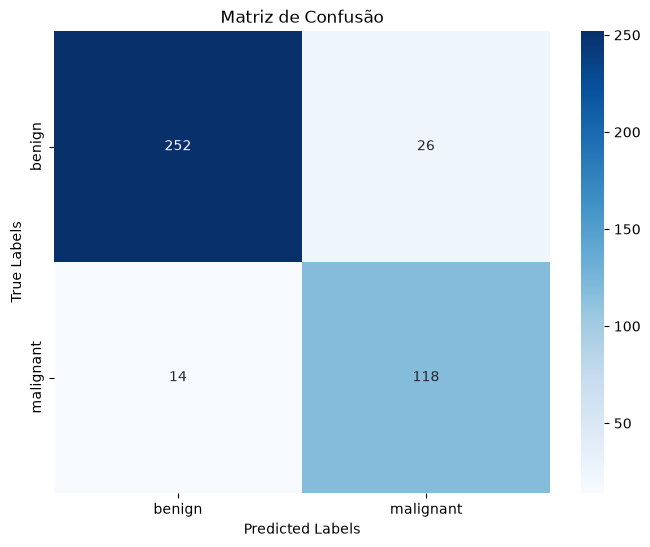

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mostrar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['benign', 'malignant'],
            yticklabels=['benign', 'malignant'])
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Matriz de Confusão')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


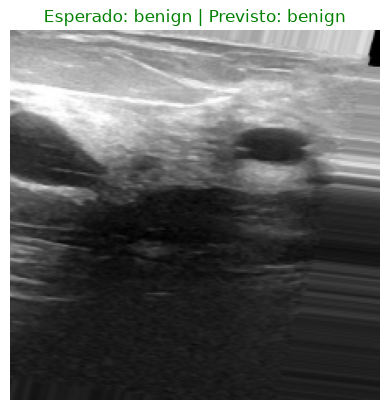

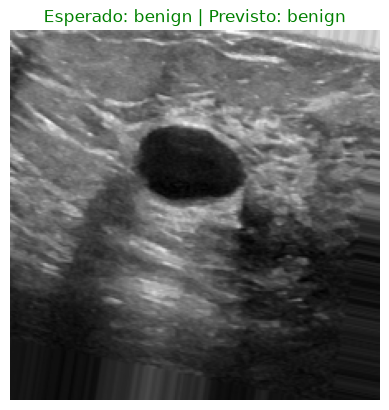

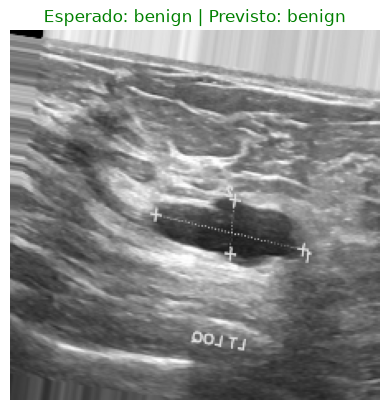

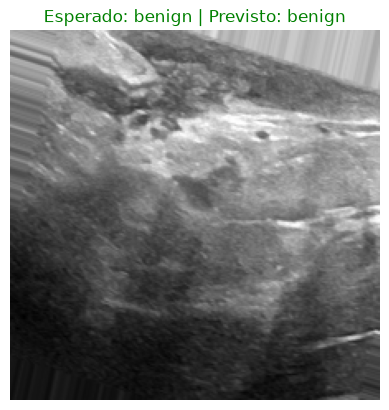

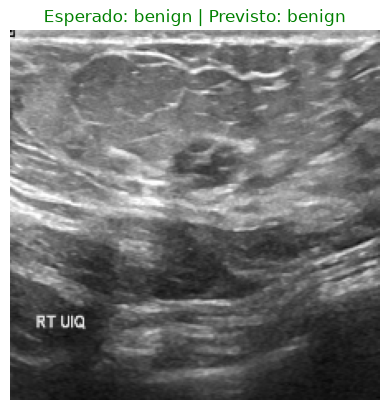

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Dicionário com as duas classes
class_names = {0: 'benign', 1: 'malignant'}

# Número de amostras que você quer prever
num_samples = 5

# Predição
predictions = model.predict(X_test[:num_samples])
predicted_classes = np.argmax(predictions, axis=1)

# Mostrar as imagens com a classe real e a prevista
for i in range(num_samples):
    plt.imshow(X_test[i].squeeze(), cmap='gray')  # .squeeze() remove canal extra se tiver
    esperado = class_names[y_test[i]]
    previsto = class_names[predicted_classes[i]]
    cor_titulo = 'green' if esperado == previsto else 'red'
    
    plt.title(f"Esperado: {esperado} | Previsto: {previsto}", color=cor_titulo)
    plt.axis('off')
    plt.show()


In [115]:
import os
import cv2
import numpy as np

# Caminhos das pastas
benign_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/validation/benign'
malignant_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/validation/malignant'

# Parâmetros
img_sz = 224
class_names = {0: 'benign', 1: 'malignant'}

def load_images_from_folder(folder_path, label):
    images = []
    labels = []

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            img = cv2.resize(img, (img_sz, img_sz))
            img = img.astype('float32') / 255.0
            img = np.expand_dims(img, axis=-1)  # (224, 224, 1)

            images.append(img)
            labels.append(label)

    return images, labels


In [116]:
benign_imgs, benign_labels = load_images_from_folder(benign_path, 0)
malignant_imgs, malignant_labels = load_images_from_folder(malignant_path, 1)

X_val = np.array(benign_imgs + malignant_imgs)
y_val = np.array(benign_labels + malignant_labels)

print(f'Total de imagens: {X_val.shape[0]}')
print(f'Benign: {np.sum(y_val == 0)} | Malignant: {np.sum(y_val == 1)}')


Total de imagens: 73
Benign: 47 | Malignant: 26


In [117]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Accuracy on test set: {accuracy*100:.2f}%")

Accuracy on test set: 72.60%


In [118]:
from sklearn.metrics import confusion_matrix

# Predição
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Matriz de confusão
conf_mat = confusion_matrix(y_val, y_pred_classes)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [119]:
from sklearn.metrics import classification_report
import numpy as np

# 🔹 Predições no conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 🔹 Checagem de consistência (ESSENCIAL)
print(len(y_val), len(y_pred_classes))  # Deve ser: 900 900

# 🔹 Relatório de classificação
print(classification_report(
    y_val,
    y_pred_classes,
    target_names=['benign', 'malignant']
))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
73 73
              precision    recall  f1-score   support

      benign       0.78      0.81      0.79        47
   malignant       0.62      0.58      0.60        26

    accuracy                           0.73        73
   macro avg       0.70      0.69      0.70        73
weighted avg       0.72      0.73      0.72        73



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
73 73


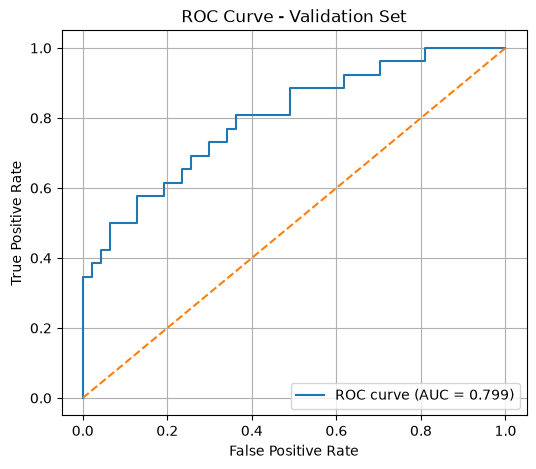

In [120]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 🔹 1. Recalcular predições com o conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)

# 🔹 2. Pegar probabilidade da classe positiva (malignant = 1)
y_scores = y_pred_probs[:, 1]

# 🔹 3. Conferência (boa prática)
print(len(y_val), len(y_scores))  # Deve ser: 900 900

# 🔹 4. Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)

# 🔹 5. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

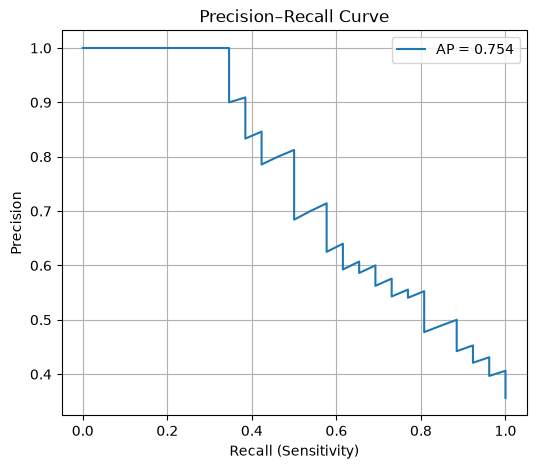

In [121]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, y_scores)
ap_score = average_precision_score(y_val, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [122]:
print(len(y_val), len(y_pred_classes))

73 73


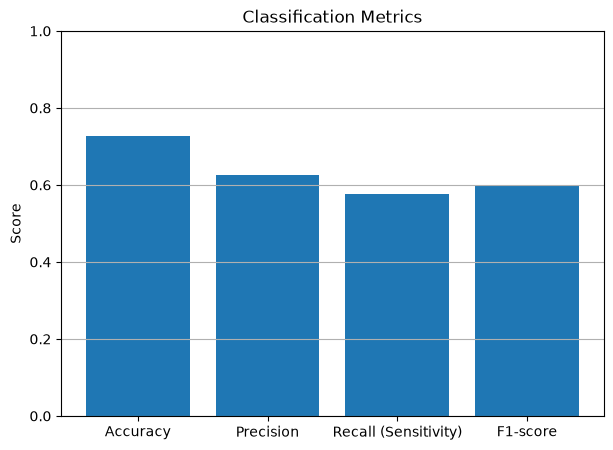

In [123]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred_classes)
precision = precision_score(y_val, y_pred_classes)
recall = recall_score(y_val, y_pred_classes)   # Sensibilidade (malignant)
f1 = f1_score(y_val, y_pred_classes)

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'F1-score': f1
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classification Metrics')
plt.grid(axis='y')
plt.show()


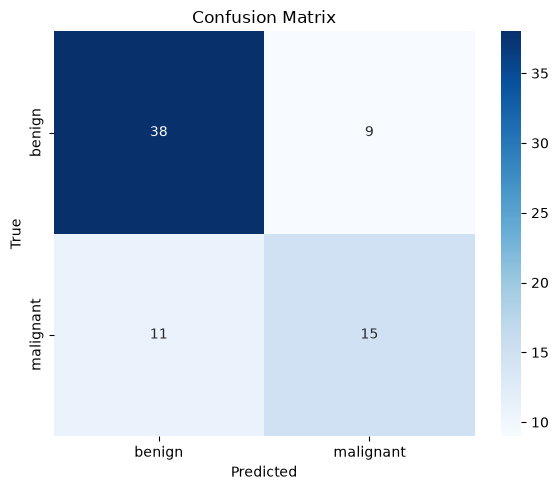

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['benign', 'malignant'],
    yticklabels=['benign', 'malignant']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


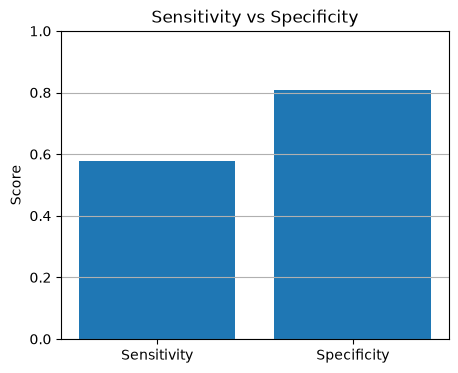

In [125]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

plt.figure(figsize=(5, 4))
plt.bar(['Sensitivity', 'Specificity'], [sensitivity, specificity])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Sensitivity vs Specificity')
plt.grid(axis='y')
plt.show()


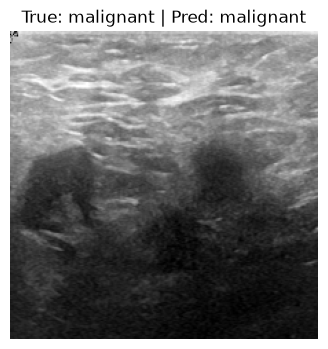

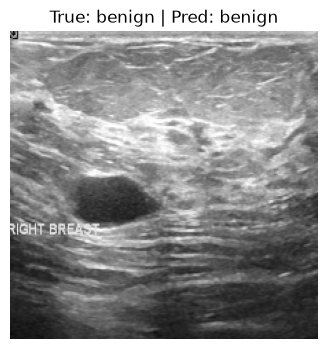

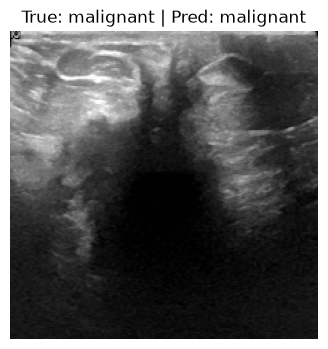

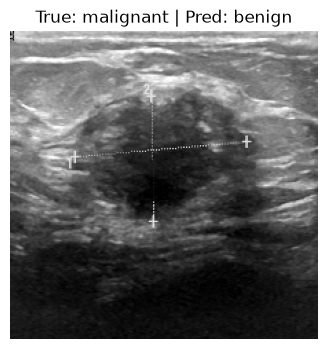

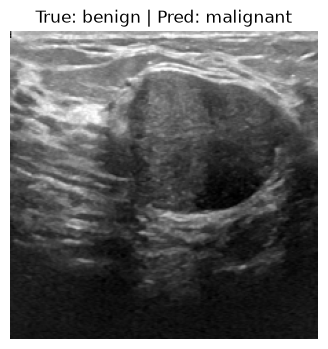

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# Número de imagens para visualização
num_images = 5

# (Opcional) Para reprodutibilidade
np.random.seed(42)

for _ in range(num_images):
    # Índice aleatório
    random_idx = np.random.randint(0, len(X_val))

    # Imagem
    img = X_val[random_idx].squeeze()

    # Rótulos
    true_label = class_names[y_val[random_idx]]
    pred_label = class_names[y_pred_classes[random_idx]]

    # Plot
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
    plt.show()



RESULTADO DA CLASSIFICAÇÃO
Arquivo: benign (204).png
Classe real: benign
Classe prevista: benign
Confiança: 1.0000
Probabilidades: [9.9999988e-01 6.0069944e-08]
Resultado: CORRETO


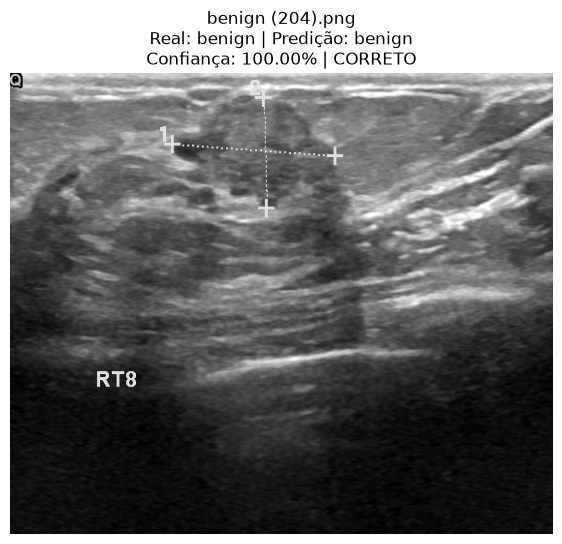

In [127]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CAMINHO DO CONJUNTO DE TESTE
# ============================================================

test_dir = (
    '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/'
    'BUSI_CLEAN/test'
)


# ============================================================
# PARÂMETROS
# ============================================================

img_sz = 224

class_names = {
    0: 'benign',
    1: 'malignant'
}


# ============================================================
# SELECIONAR UMA IMAGEM ALEATÓRIA
# ENTRE AS DUAS CLASSES
# ============================================================

image_list = []

for class_name in ['benign', 'malignant']:

    class_dir = os.path.join(
        test_dir,
        class_name
    )

    for filename in os.listdir(class_dir):

        if filename.lower().endswith(
            ('.png', '.jpg', '.jpeg')
        ):

            image_list.append(
                (
                    os.path.join(
                        class_dir,
                        filename
                    ),
                    class_name,
                    filename
                )
            )


if len(image_list) == 0:
    raise ValueError(
        "Nenhuma imagem encontrada no conjunto de teste."
    )


# Seleciona uma imagem aleatória
img_path, real_class, filename = random.choice(
    image_list
)


# ============================================================
# FUNÇÃO DE PRÉ-PROCESSAMENTO
# ============================================================

def preprocess_image(img_path):

    # Carregar como grayscale
    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError(
            f"Erro ao carregar a imagem: {img_path}"
        )

    # Redimensionar
    img = cv2.resize(
        img,
        (img_sz, img_sz)
    )

    # Converter para float32
    img = img.astype('float32')

    # Normalizar para intervalo [0,1]
    img = img / 255.0

    # (224,224) -> (224,224,1)
    img = np.expand_dims(
        img,
        axis=-1
    )

    # (224,224,1) -> (1,224,224,1)
    img = np.expand_dims(
        img,
        axis=0
    )

    return img


# ============================================================
# PRÉ-PROCESSAR IMAGEM
# ============================================================

img_input = preprocess_image(
    img_path
)


# ============================================================
# FAZER PREDIÇÃO
# ============================================================

pred_probs = model.predict(
    img_input,
    verbose=0
)

pred_class = np.argmax(
    pred_probs,
    axis=1
)[0]

confidence = np.max(
    pred_probs
)

predicted_class = class_names[
    pred_class
]


# ============================================================
# VERIFICAR SE A PREDIÇÃO ESTÁ CORRETA
# ============================================================

correct = (
    predicted_class == real_class
)


# ============================================================
# MOSTRAR RESULTADO
# ============================================================

print("\n====================================")
print("RESULTADO DA CLASSIFICAÇÃO")
print("====================================")

print(f"Arquivo: {filename}")

print(f"Classe real: {real_class}")

print(
    f"Classe prevista: {predicted_class}"
)

print(
    f"Confiança: {confidence:.4f}"
)

print(
    f"Probabilidades: {pred_probs[0]}"
)


if correct:

    print("Resultado: CORRETO")

else:

    print("Resultado: INCORRETO")


# ============================================================
# EXIBIR IMAGEM
# ============================================================

img_display = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)


plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    img_display,
    cmap='gray'
)


status = (
    "CORRETO"
    if correct
    else "INCORRETO"
)


plt.title(
    f"{filename}\n"
    f"Real: {real_class} | "
    f"Predição: {predicted_class}\n"
    f"Confiança: {confidence:.2%} | "
    f"{status}"
)


plt.axis('off')

plt.show()

Colunas do CSV:
['ID', 'Pathology', 'kFold', 'valid_1', 'valid_2', 'valid_3', 'valid_4', 'valid_5']

Imagem selecionada:
bus_0455-l.png
ID procurado no CSV:
bus_0455-l
Classe real:
benign

RESULTADO DA CLASSIFICAÇÃO
Arquivo: bus_0455-l.png
Classe real: benign
Classe prevista: benign
Confiança: 0.9978
Probabilidades: [0.9978459  0.00215413]
Resultado: CORRETO


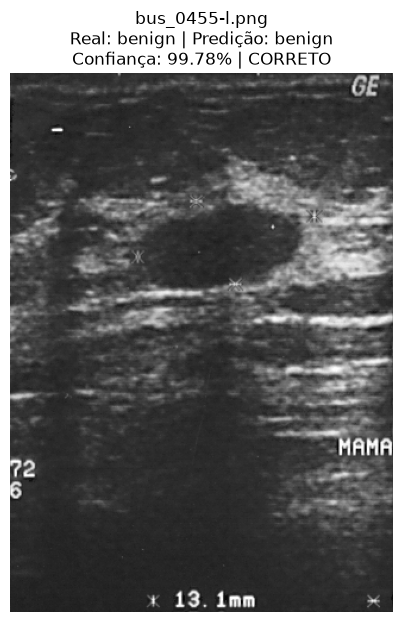

In [128]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CAMINHOS
# ============================================================

images_dir = (
    '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/'
    'BUSBRA/Images'
)

csv_path = (
    '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/'
    'BUSBRA/5-fold-cv.csv'
)


# ============================================================
# CARREGAR O CSV
# ============================================================

df = pd.read_csv(csv_path)

# Remover possíveis espaços extras dos nomes das colunas
df.columns = df.columns.str.strip()

print("Colunas do CSV:")
print(df.columns.tolist())


# ============================================================
# SELECIONAR UMA IMAGEM ALEATÓRIA
# ============================================================

image_files = [
    file for file in os.listdir(images_dir)
    if file.lower().endswith(('.png', '.jpg', '.jpeg'))
]

if len(image_files) == 0:
    raise ValueError("Nenhuma imagem encontrada na pasta.")


selected_image = random.choice(image_files)

img_path = os.path.join(
    images_dir,
    selected_image
)


# ============================================================
# OBTER O ID DA IMAGEM
#
# Exemplo:
# bus_0930-r.png -> bus_0930-r
# ============================================================

image_id = os.path.splitext(selected_image)[0]


# ============================================================
# PROCURAR A CLASSE REAL NO CSV
# ============================================================

# Garantir que ID seja string e sem espaços extras
df['ID'] = df['ID'].astype(str).str.strip()

row = df[df['ID'] == image_id]


if row.empty:

    real_class = "não encontrada"

    print(
        f"\nAVISO: o ID {image_id} "
        "não foi encontrado no arquivo CSV."
    )

else:

    real_class = (
        row.iloc[0]['Pathology']
    )

    real_class = str(
        real_class
    ).strip().lower()


print("\nImagem selecionada:")
print(selected_image)

print("ID procurado no CSV:")
print(image_id)

print("Classe real:")
print(real_class)


# ============================================================
# PARÂMETROS DO MODELO
# ============================================================

img_sz = 224

class_names = {
    0: 'benign',
    1: 'malignant'
}


# ============================================================
# PRÉ-PROCESSAMENTO
# ============================================================

def preprocess_image(img_path):

    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError(
            f"Erro ao carregar a imagem: {img_path}"
        )

    # Redimensionar
    img = cv2.resize(
        img,
        (img_sz, img_sz)
    )

    # Converter para float
    img = img.astype('float32')

    # Normalização
    img = img / 255.0

    # (224,224) -> (224,224,1)
    img = np.expand_dims(
        img,
        axis=-1
    )

    # (224,224,1) -> (1,224,224,1)
    img = np.expand_dims(
        img,
        axis=0
    )

    return img


# ============================================================
# PRÉ-PROCESSAR
# ============================================================

img_input = preprocess_image(
    img_path
)


# ============================================================
# PREDIÇÃO
# ============================================================

pred_probs = model.predict(
    img_input,
    verbose=0
)

pred_class = np.argmax(
    pred_probs,
    axis=1
)[0]

confidence = np.max(
    pred_probs
)

predicted_class = class_names[
    pred_class
]


# ============================================================
# VERIFICAR SE ACERTOU
# ============================================================

if real_class != "não encontrada":

    correct = (
        predicted_class.lower()
        ==
        real_class.lower()
    )

else:

    correct = False


# ============================================================
# MOSTRAR RESULTADO
# ============================================================

print("\n====================================")
print("RESULTADO DA CLASSIFICAÇÃO")
print("====================================")

print(
    f"Arquivo: {selected_image}"
)

print(
    f"Classe real: {real_class}"
)

print(
    f"Classe prevista: {predicted_class}"
)

print(
    f"Confiança: {confidence:.4f}"
)

print(
    f"Probabilidades: {pred_probs[0]}"
)


if real_class != "não encontrada":

    if correct:

        print("Resultado: CORRETO")

    else:

        print("Resultado: INCORRETO")


# ============================================================
# EXIBIR IMAGEM
# ============================================================

img_display = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)


plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    img_display,
    cmap='gray'
)


if real_class != "não encontrada":

    status = (
        "CORRETO"
        if correct
        else "INCORRETO"
    )

    plt.title(
        f"{selected_image}\n"
        f"Real: {real_class} | "
        f"Predição: {predicted_class}\n"
        f"Confiança: {confidence:.2%} | "
        f"{status}"
    )

else:

    plt.title(
        f"{selected_image}\n"
        f"Predição: {predicted_class} "
        f"({confidence:.2%})\n"
        f"Classe real não encontrada"
    )


plt.axis('off')

plt.show()